<a href="https://colab.research.google.com/github/honeykgarg/PyTorch_NN/blob/LogisticRegression/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
!pip install --upgrade kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 7.9 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.13
    Uninstalling kagglehub-0.3.13:
      Successfully uninstalled kagglehub-0.3.13


In [3]:
import kagglehub
# You may need to re-run this cell after logging in.
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [4]:
path = kagglehub.dataset_download("mohansacharya/graduate-admissions")

Using Colab cache for faster access to the 'graduate-admissions' dataset.


In [5]:
path

'/kaggle/input/graduate-admissions'

In [9]:
data  = pd.read_csv(path+'//Admission_Predict.csv')

In [13]:
data.shape

(400, 9)

In [15]:
data.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [19]:
data = data.rename(index=str, columns={'Chance of Admit ': 'Admit_Probability'})
data = data[['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA','Research','Admit_Probability']]

In [20]:
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Admit_Probability
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


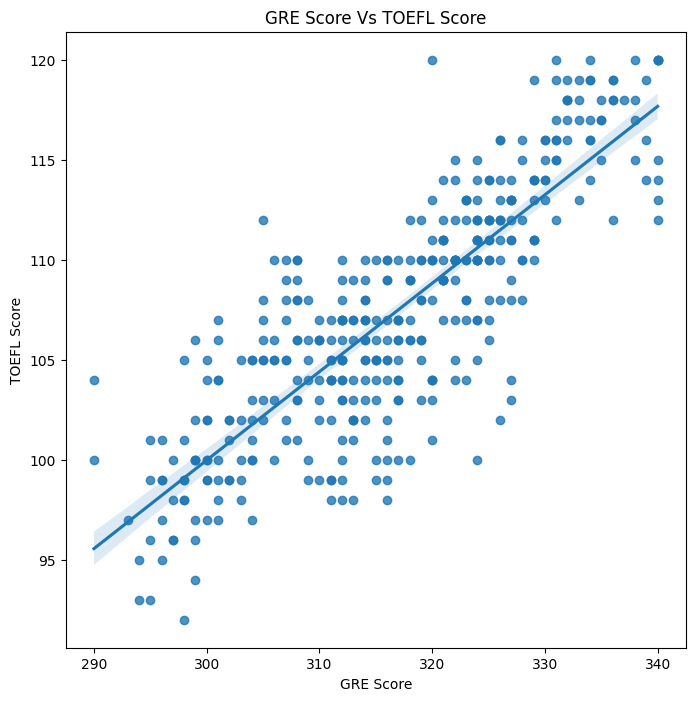

In [22]:
plt.figure(figsize=(8,8))

fig = sns.regplot(x="GRE Score", y= "TOEFL Score", data= data)
plt.title("GRE Score Vs TOEFL Score")
plt.show()

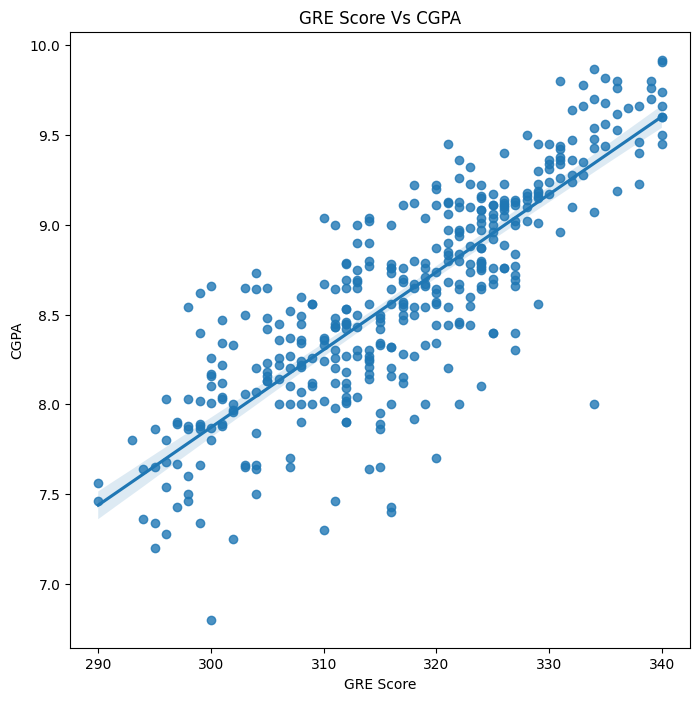

In [23]:
plt.figure(figsize=(8,8))

fig = sns.regplot(x="GRE Score", y= "CGPA", data= data)
plt.title("GRE Score Vs CGPA")
plt.show()

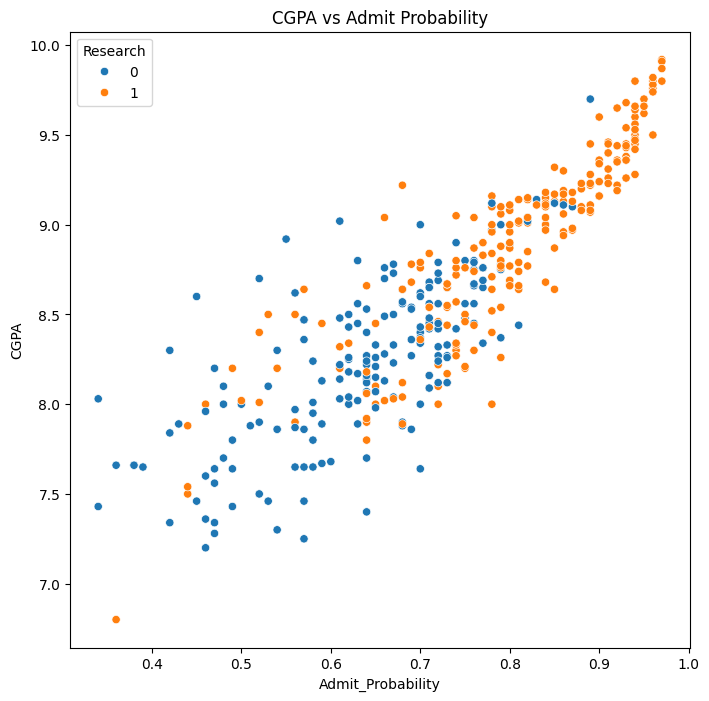

In [26]:
plt.figure(figsize=(8,8))

fig = sns.scatterplot(x="Admit_Probability", y= "CGPA", data= data, hue='Research')
plt.title("CGPA vs Admit Probability")
plt.show()

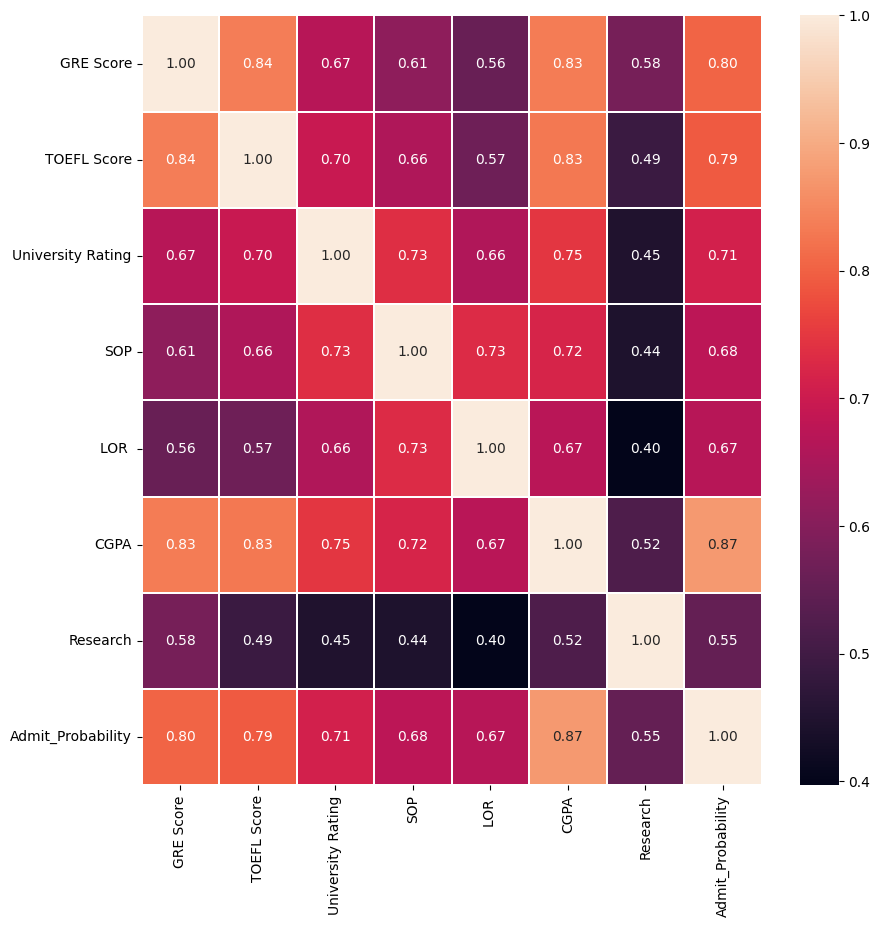

In [28]:
plt.figure(figsize=(10,10))

sns.heatmap(data.corr(), annot=True, linewidths=0.05, fmt='.2f')
plt.show()
#

In [29]:
from sklearn import preprocessing

data[['GRE Score', 'TOEFL Score', 'SOP', 'LOR ', 'CGPA']] = preprocessing.scale(data[['GRE Score', 'TOEFL Score', 'SOP', 'LOR ', 'CGPA']])

In [32]:
data.iloc[25]

,25
GRE Score,2.023903
TOEFL Score,2.076899
University Rating,5.000000
SOP,1.093864
LOR,1.167321
CGPA,1.680865
Research,1.000000
Admit_Probability,0.940000


In [33]:
col = ['GRE Score', 'TOEFL Score', 'SOP', 'LOR ', 'CGPA']
features= data[col]

In [34]:
features.head()

,GRE Score,TOEFL Score,SOP,LOR,CGPA
0,1.762107,1.746971,1.093864,1.167321,1.764818
1,0.627656,-0.067635,0.596653,1.167321,0.455151
2,-0.070467,-0.562528,-0.397769,0.052933,-1.005631
3,0.453126,0.427257,0.099442,-1.061454,0.119339
4,-0.244998,-0.727492,-1.392191,-0.504260,-0.653029


In [35]:
target = data[['Admit_Probability']]

In [36]:
y = target.copy()

In [38]:
y['Admit_Probability'] = 0 # Default to 0 (for values < 0.60)
y.loc[target['Admit_Probability'] >= 0.60, 'Admit_Probability'] = 1
y.loc[target['Admit_Probability'] >= 0.80, 'Admit_Probability'] = 2

In [39]:
y.head()

,Admit_Probability
0,2
1,1
2,1
3,2
4,1


In [40]:
target.head()

,Admit_Probability
0,0.92
1,0.76
2,0.72
3,0.80
4,0.65


In [41]:
target = y

In [42]:
target['Admit_Probability'].unique()

array([2, 1, 0])

In [43]:
from sklearn.model_selection import train_test_split

In [45]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

In [47]:
xTrain = torch.from_numpy(x_train.values).float()
xTest = torch.from_numpy(x_test.values).float()

In [50]:
xTrain.shape

torch.Size([320, 5])

In [51]:
yTrain = torch.from_numpy(y_train.values).view(1,-1)[0].long()
yTest = torch.from_numpy(y_test.values).view(1,-1)[0].long()

In [52]:
import torch.nn as nn
import torch.nn.functional as F

In [53]:
input_size = xTrain.shape[1]
output_size = len(target['Admit_Probability'].unique())

In [68]:
class Net(nn.Module):

  def __init__(self,hidden_size, activation_fn= 'relu', apply_dropout = False):
      super(Net, self).__init__()
      self.fc1 = nn.Linear(input_size, hidden_size)
      self.fc2 = nn.Linear(hidden_size, hidden_size)
      self.fc3 = nn.Linear(hidden_size, output_size)

      self.hidden_size = hidden_size
      self.activation_fn = activation_fn
      self.dropout = None
      if apply_dropout:
          self.dropout = nn.Dropout(0.2)


  def forward(self, x):
      activation_fn = None
      if self.activation_fn == 'sigmoid':
        activation_fn = F.torch.sigmoid

      elif self.activation_fn == 'tanh':
        activation_fn = F.torch.tanh

      elif self.activation_fn == 'relu':
        activation_fn = F.relu

      x = activation_fn(self.fc1(x))
      x = activation_fn(self.fc2(x))

      if self.dropout!= None:
          x = self.dropout(x)

      x = self.fc3(x)

      return F.log_softmax(x, dim = -1)


In [69]:
import torch.optim as optim

In [104]:
def train_evaluate_model(model, learn_rate=0.001):
  epoch_data = []
  epochs = 5001

  optimizer = optim.Adam(model.parameters(), lr=learn_rate)
  loss_fn = nn.NLLLoss()

  test_accuracy = 0.0

  for epoch in range(1,epochs):
    optimizer.zero_grad()

    model.train()
    yPred = model(xTrain)
    loss = loss_fn(yPred, yTrain)
    loss.backward()
    optimizer.step()
    model.eval()
    yPred_test = model(xTest)
    loss_test = loss_fn(yPred_test, yTest)
    _, pred = yPred_test.data.max(1)

    test_accuracy = pred.eq(yTest.data).sum().item()/y_test.values.size

    epoch_data.append([epoch, loss.data.item(), loss_test.data.item(), test_accuracy])

    if epoch % 100 == 0:
      print('epoch - %d (%d%%) train loss - %.2f test loss - %.2f Test accuracy - %.4f' \
      % (epoch, epoch/150 * 10, loss.data.item(), loss_test.data.item(), test_accuracy))

  return {'model' : model,
          'epoch_Data' : epoch_data,
          'num_epochs' : epochs,
          'optimizer' : optimizer,
          'loss_fn' : loss_fn,
          'test_accuracy' : test_accuracy,
          '_,pred' : yPred_test.data.max(1),
          'actual_test_label' : yTest
          }




In [97]:
net = Net(hidden_size = 3, activation_fn='sigmoid', apply_dropout=False)
net

Net(
  (fc1): Linear(in_features=5, out_features=3, bias=True)
  (fc2): Linear(in_features=3, out_features=3, bias=True)
  (fc3): Linear(in_features=3, out_features=3, bias=True)
)

In [98]:
result_3_sigmoid = train_evaluate_model(net)

epoch - 100 (6%) train loss - 1.05 test loss - 0.99 Test accuracy - 0.6000
epoch - 200 (13%) train loss - 1.03 test loss - 0.97 Test accuracy - 0.6000
epoch - 300 (20%) train loss - 1.01 test loss - 0.95 Test accuracy - 0.6000
epoch - 400 (26%) train loss - 0.99 test loss - 0.93 Test accuracy - 0.6000
epoch - 500 (33%) train loss - 0.95 test loss - 0.90 Test accuracy - 0.6000
epoch - 600 (40%) train loss - 0.90 test loss - 0.86 Test accuracy - 0.7750
epoch - 700 (46%) train loss - 0.84 test loss - 0.81 Test accuracy - 0.7375
epoch - 800 (53%) train loss - 0.79 test loss - 0.77 Test accuracy - 0.7125
epoch - 900 (60%) train loss - 0.74 test loss - 0.73 Test accuracy - 0.7125
epoch - 1000 (66%) train loss - 0.70 test loss - 0.70 Test accuracy - 0.7125
epoch - 1100 (73%) train loss - 0.67 test loss - 0.68 Test accuracy - 0.7125
epoch - 1200 (80%) train loss - 0.65 test loss - 0.66 Test accuracy - 0.7125
epoch - 1300 (86%) train loss - 0.64 test loss - 0.65 Test accuracy - 0.7125
epoch - 1

In [99]:
net1 = Net(hidden_size = 3, activation_fn='sigmoid', apply_dropout=True)
net1

Net(
  (fc1): Linear(in_features=5, out_features=3, bias=True)
  (fc2): Linear(in_features=3, out_features=3, bias=True)
  (fc3): Linear(in_features=3, out_features=3, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [100]:
result_3_sigmoid_with_dropout = train_evaluate_model(net1)

epoch - 100 (6%) train loss - 1.05 test loss - 0.98 Test accuracy - 0.6000
epoch - 200 (13%) train loss - 1.02 test loss - 0.97 Test accuracy - 0.6000
epoch - 300 (20%) train loss - 1.00 test loss - 0.95 Test accuracy - 0.6000
epoch - 400 (26%) train loss - 0.95 test loss - 0.92 Test accuracy - 0.6000
epoch - 500 (33%) train loss - 0.94 test loss - 0.89 Test accuracy - 0.7875
epoch - 600 (40%) train loss - 0.86 test loss - 0.84 Test accuracy - 0.7250
epoch - 700 (46%) train loss - 0.85 test loss - 0.80 Test accuracy - 0.7125
epoch - 800 (53%) train loss - 0.77 test loss - 0.76 Test accuracy - 0.7125
epoch - 900 (60%) train loss - 0.73 test loss - 0.73 Test accuracy - 0.7125
epoch - 1000 (66%) train loss - 0.73 test loss - 0.70 Test accuracy - 0.7125
epoch - 1100 (73%) train loss - 0.70 test loss - 0.68 Test accuracy - 0.7125
epoch - 1200 (80%) train loss - 0.70 test loss - 0.67 Test accuracy - 0.7125
epoch - 1300 (86%) train loss - 0.68 test loss - 0.65 Test accuracy - 0.7125
epoch - 1

In [106]:
net2 = Net(hidden_size = 5, activation_fn='tanh')
net2

Net(
  (fc1): Linear(in_features=5, out_features=5, bias=True)
  (fc2): Linear(in_features=5, out_features=5, bias=True)
  (fc3): Linear(in_features=5, out_features=3, bias=True)
)

In [107]:
result_3_tanh = train_evaluate_model(net2)

epoch - 100 (6%) train loss - 0.90 test loss - 0.88 Test accuracy - 0.7000
epoch - 200 (13%) train loss - 0.70 test loss - 0.69 Test accuracy - 0.7125
epoch - 300 (20%) train loss - 0.59 test loss - 0.59 Test accuracy - 0.7250
epoch - 400 (26%) train loss - 0.54 test loss - 0.54 Test accuracy - 0.7250
epoch - 500 (33%) train loss - 0.50 test loss - 0.50 Test accuracy - 0.8250
epoch - 600 (40%) train loss - 0.48 test loss - 0.47 Test accuracy - 0.8250
epoch - 700 (46%) train loss - 0.47 test loss - 0.45 Test accuracy - 0.8375
epoch - 800 (53%) train loss - 0.46 test loss - 0.43 Test accuracy - 0.8250
epoch - 900 (60%) train loss - 0.45 test loss - 0.42 Test accuracy - 0.8250
epoch - 1000 (66%) train loss - 0.44 test loss - 0.42 Test accuracy - 0.8375
epoch - 1100 (73%) train loss - 0.44 test loss - 0.41 Test accuracy - 0.8375
epoch - 1200 (80%) train loss - 0.43 test loss - 0.41 Test accuracy - 0.8500
epoch - 1300 (86%) train loss - 0.43 test loss - 0.41 Test accuracy - 0.8500
epoch - 1